   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

  species  
0  Setosa  
1  Setosa  
2  Setosa  
3  Setosa  
4  Setosa  


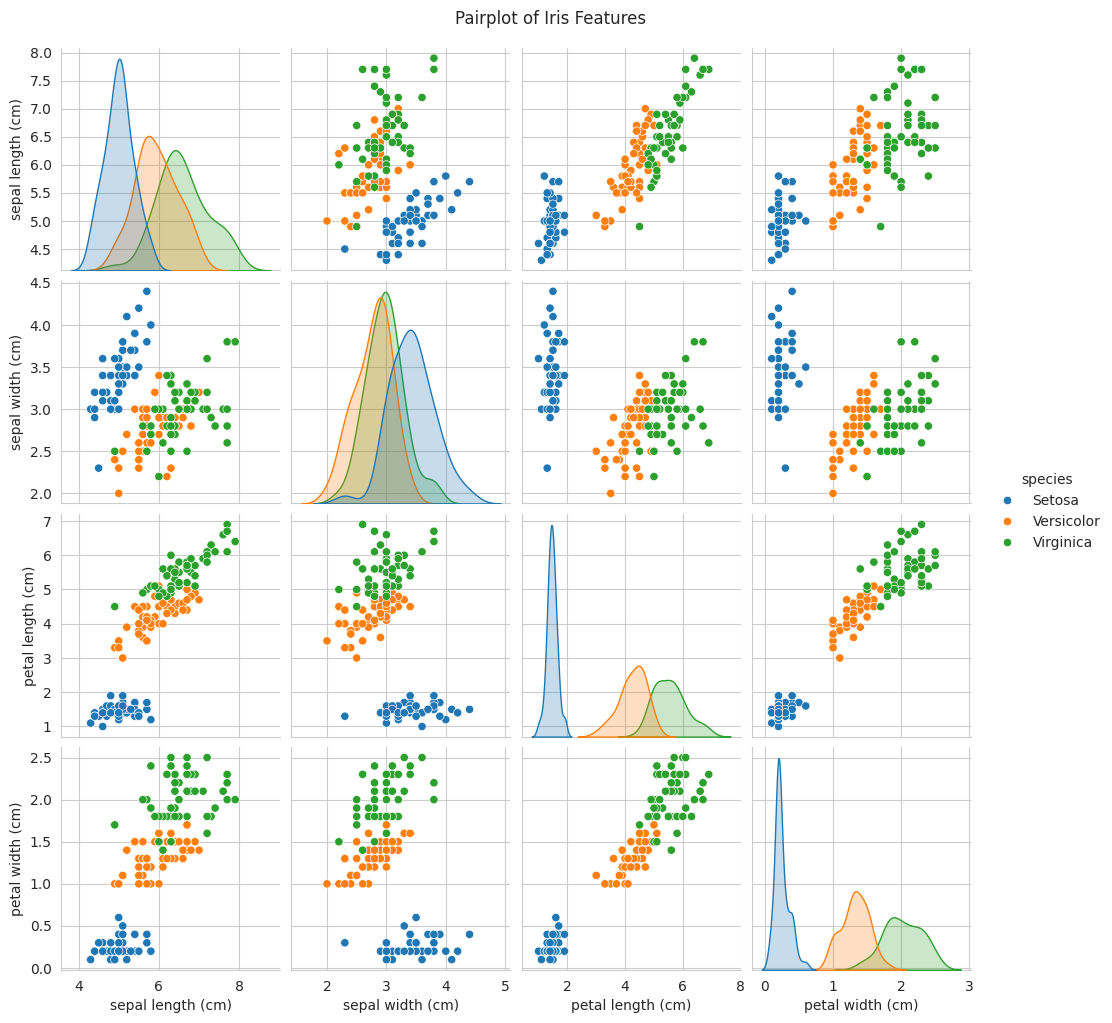

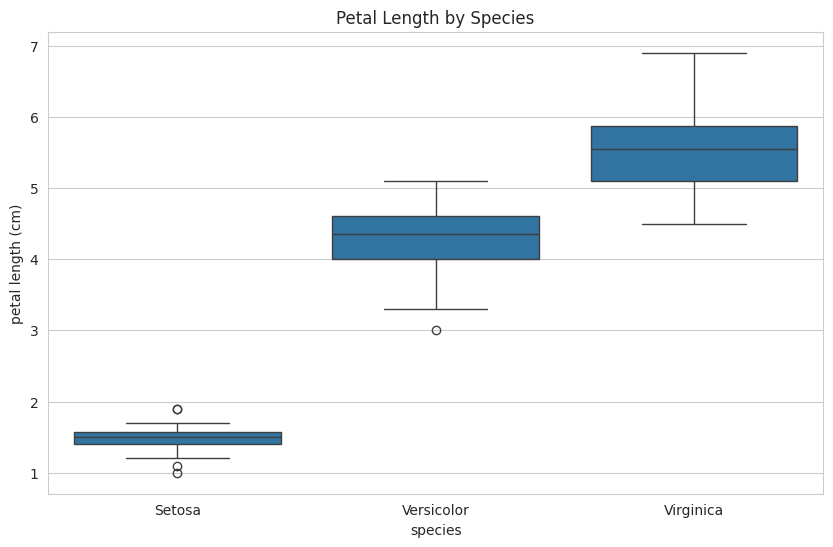

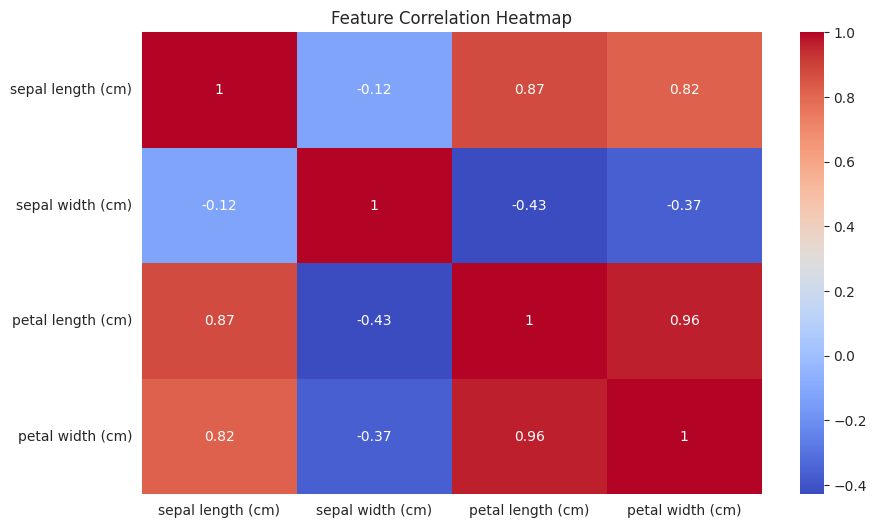

📌 Logistic Regression Accuracy: 1.0
📌 Random Forest Accuracy: 1.0

Classification Report (Random Forest):

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



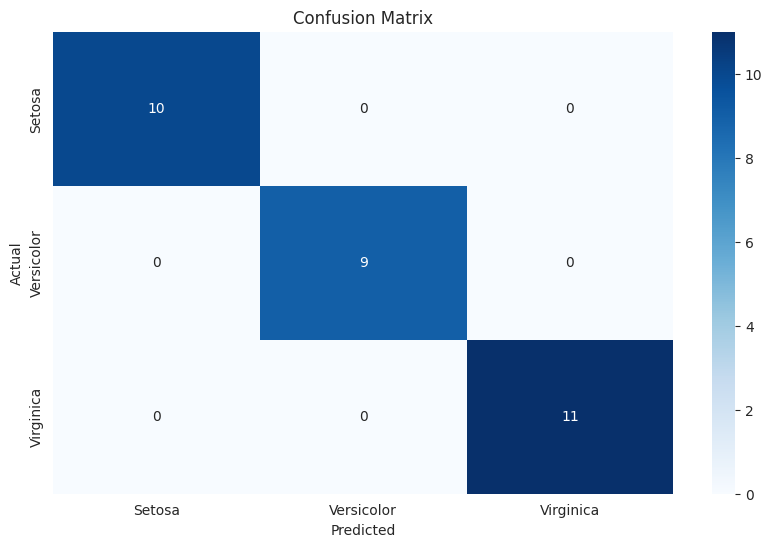

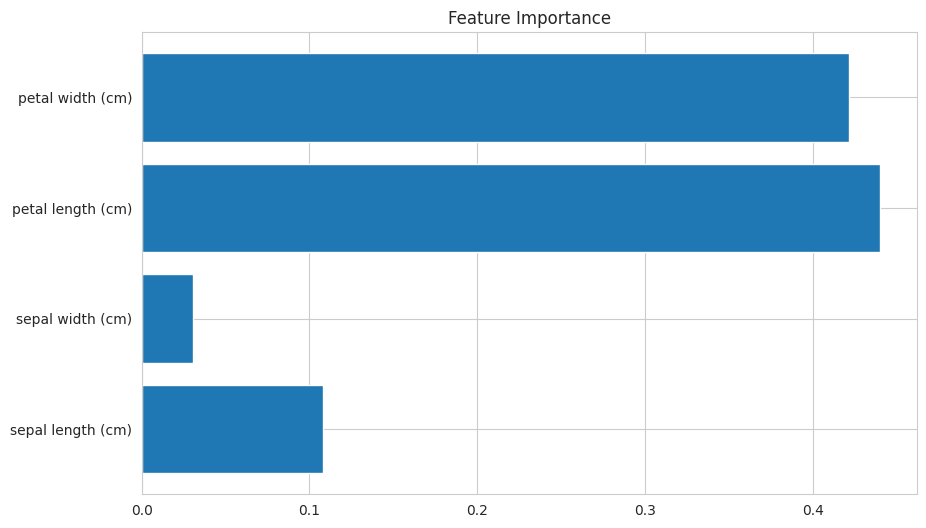

In [ ]:
# ==========================================
# 🌸 Iris Flower Classification (Advanced)
# ==========================================

# Step 1: Import libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10,6)

# Step 2: Load dataset (inbuilt)
from sklearn.datasets import load_iris

iris = load_iris()

# Convert to DataFrame
data = pd.DataFrame(iris.data, columns=iris.feature_names)
data['species'] = iris.target

# Convert numeric target to names
data['species'] = data['species'].map({
    0: 'Setosa',
    1: 'Versicolor',
    2: 'Virginica'
})

print(data.head())

# ==========================================
# 📊 DATA VISUALIZATION (IMPRESSIVE)
# ==========================================

# 1. Pairplot (VERY IMPORTANT 🔥)
sns.pairplot(data, hue='species')
plt.suptitle("Pairplot of Iris Features", y=1.02)
plt.show()

# 2. Boxplot
sns.boxplot(x='species', y='petal length (cm)', data=data)
plt.title("Petal Length by Species")
plt.show()

# 3. Heatmap
corr = data.drop('species', axis=1).corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Feature Correlation Heatmap")
plt.show()

# ==========================================
# 🤖 MODEL BUILDING
# ==========================================

# Convert species back to numbers for model
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
data['species_encoded'] = le.fit_transform(data['species'])

# Features & Target
X = data.drop(['species', 'species_encoded'], axis=1)
y = data['species_encoded']

# Split data
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ==========================================
# 🔥 MODEL 1: Logistic Regression
# ==========================================
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=200)
lr.fit(X_train, y_train)

# ==========================================
# 🔥 MODEL 2: Random Forest (BEST)
# ==========================================
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

# ==========================================
# 📊 EVALUATION
# ==========================================

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Predictions
y_pred_lr = lr.predict(X_test)
y_pred_rf = rf.predict(X_test)

print("📌 Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_lr))
print("📌 Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))

print("\nClassification Report (Random Forest):\n")
print(classification_report(y_test, y_pred_rf))

# ==========================================
# 🔥 CONFUSION MATRIX (VERY IMPORTANT)
# ==========================================

cm = confusion_matrix(y_test, y_pred_rf)

sns.heatmap(cm, annot=True, cmap='Blues',
            xticklabels=le.classes_,
            yticklabels=le.classes_)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

# ==========================================
# 🌟 FEATURE IMPORTANCE (IMPRESSIVE)
# ==========================================

importances = rf.feature_importances_

plt.barh(X.columns, importances)
plt.title("Feature Importance")
plt.show()

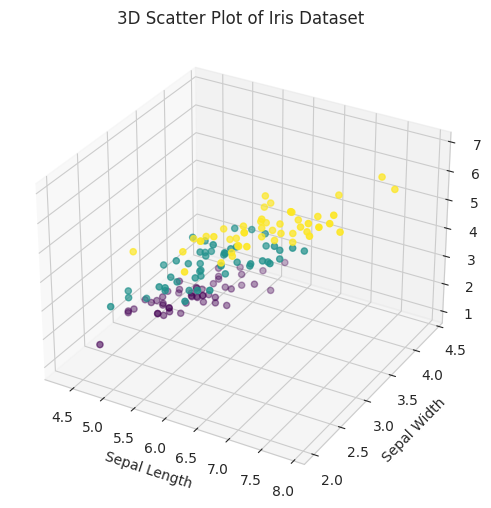

In [ ]:
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(data['sepal length (cm)'],
           data['sepal width (cm)'],
           data['petal length (cm)'],
           c=data['species_encoded'],
           cmap='viridis')

ax.set_xlabel('Sepal Length')
ax.set_ylabel('Sepal Width')
ax.set_zlabel('Petal Length')
plt.title("3D Scatter Plot of Iris Dataset")
plt.show()

/tmp/ipykernel_4991/3677154319.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='species', y='petal width (cm)', data=data, palette='Pastel1')


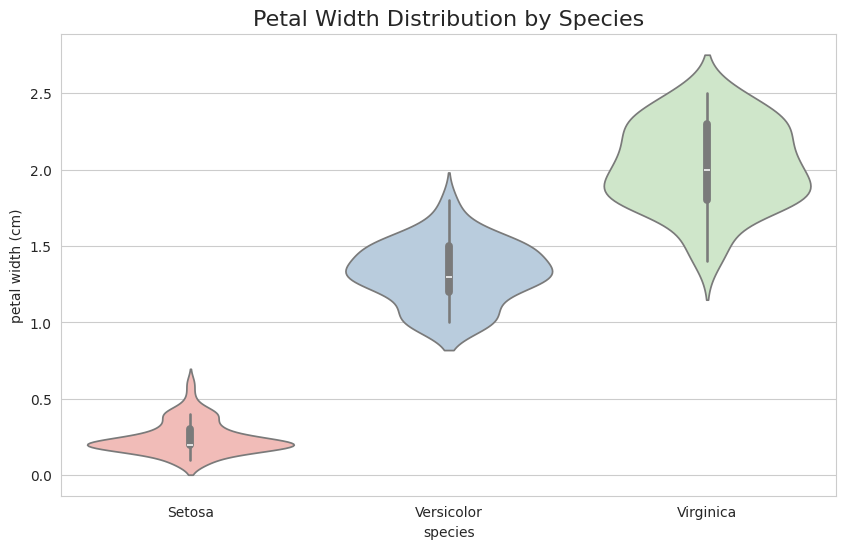

In [ ]:
sns.violinplot(x='species', y='petal width (cm)', data=data, palette='Pastel1')
plt.title("Petal Width Distribution by Species", fontsize=16)
plt.show()

/tmp/ipykernel_4991/2677838798.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.swarmplot(x='species', y='sepal length (cm)', data=data, palette='deep')


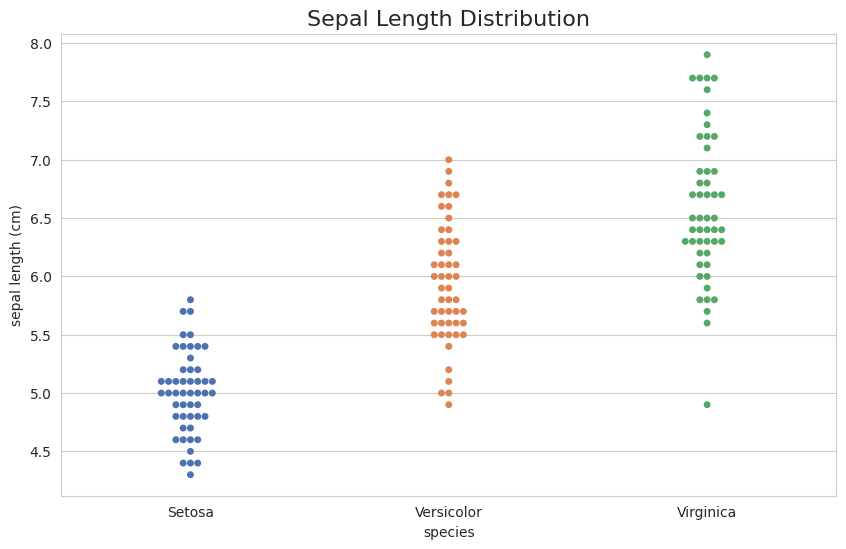

In [ ]:
sns.swarmplot(x='species', y='sepal length (cm)', data=data, palette='deep')
plt.title("Sepal Length Distribution", fontsize=16)
plt.show()